In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
url = "https://raw.githubusercontent.com/satishgunjal/datasets/master/Mall_Customers.csv"
df = pd.read_csv(url)

In [3]:
print(f"Dimensions du tableau : {df.shape}")
print(df.head())

Dimensions du tableau : (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print(df.describe())
print(df.info())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-

In [5]:
df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome', 
    'Spending Score (1-100)': 'SpendingScore'
}, inplace=True)

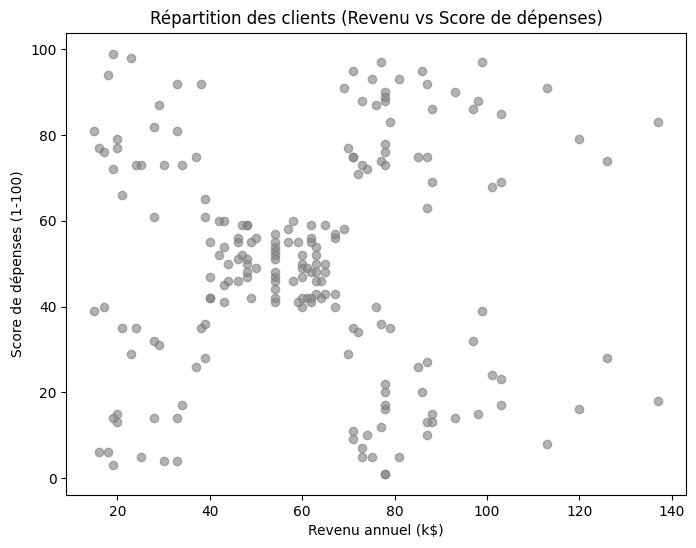

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], color='gray', alpha=0.6)
plt.title('Répartition des clients (Revenu vs Score de dépenses)')
plt.xlabel('Revenu annuel (k$)')
plt.ylabel('Score de dépenses (1-100)')
plt.show()

In [7]:
X = df.loc[:, ["AnnualIncome", "SpendingScore"]].values
print(f"Premières lignes de X :\n{X[:5]}")

Premières lignes de X :
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


In [8]:
wcss = [] # Liste pour stocker l'inertie (Within-Cluster Sum of Square)

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

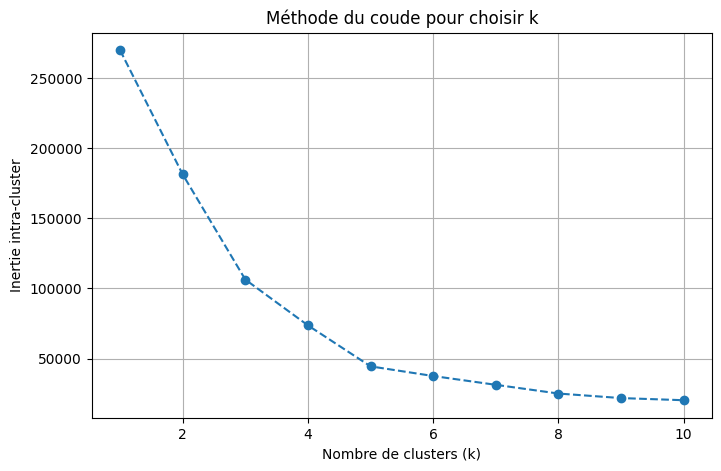

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Méthode du coude pour choisir k')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie intra-cluster')
plt.grid(True)
plt.show()

In [10]:
kmeans_final = KMeans(n_clusters=5, init='random', random_state=42)
y_kmeans = kmeans_final.fit_predict(X)

In [11]:
df['Cluster'] = y_kmeans

In [12]:
analysis = df.groupby('Cluster').agg({
    'AnnualIncome': ['mean', 'count'],
    'SpendingScore': 'mean'
})
print("Analyse par cluster :\n", analysis)

Analyse par cluster :
         AnnualIncome       SpendingScore
                mean count          mean
Cluster                                 
0          26.304348    23     20.913043
1          25.727273    22     79.363636
2          88.200000    35     17.114286
3          86.538462    39     82.128205
4          55.296296    81     49.518519


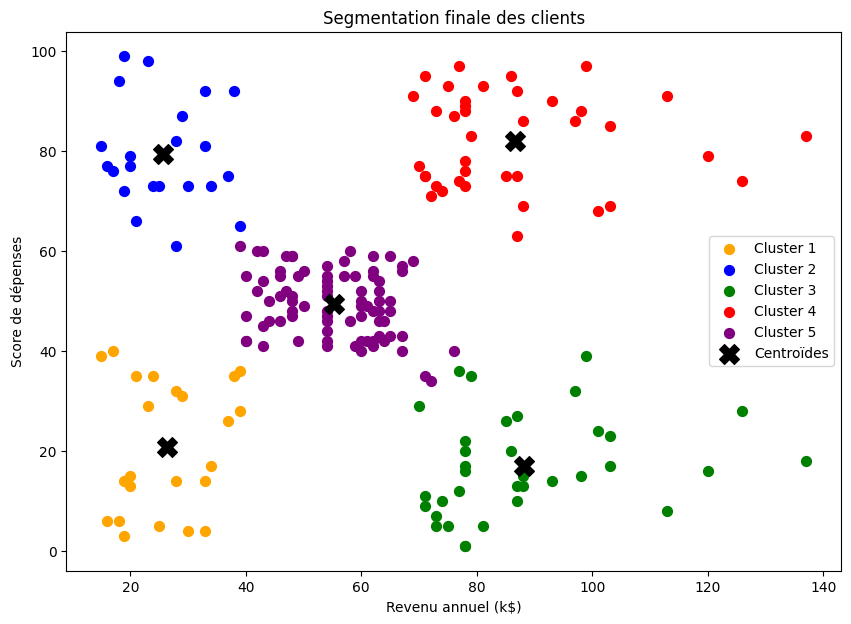

In [13]:
plt.figure(figsize=(10, 7))
colors = ['orange', 'blue', 'green', 'red', 'purple']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
            s=200, c='black', marker='X', label='Centroïdes')
plt.title('Segmentation finale des clients')
plt.xlabel('Revenu annuel (k$)')
plt.ylabel('Score de dépenses')
plt.legend()
plt.show()